# 02. 2차원 천수방정식과 Arakawa C-grid

Stage 1의 엇갈린 격자를 2차원으로 확장한다. 회전이 없는 2차원 선형 천수방정식은

$$
\frac{\partial u}{\partial t} = -g\frac{\partial \eta}{\partial x},\quad
\frac{\partial v}{\partial t} = -g\frac{\partial \eta}{\partial y},\quad
\frac{\partial \eta}{\partial t} = -H\Big(\frac{\partial u}{\partial x}+\frac{\partial v}{\partial y}\Big)
$$

이며, 속도 $c=\sqrt{gH}$ 의 중력파가 사방으로 퍼진다.

학습 목표:

1. **Arakawa C-grid** 위에 $u,v,\eta$ 를 배치한다.
2. 중심 봉우리가 동심원으로 퍼지는 **2차원 중력파 전파**를 본다.
3. 닫힌 경계(벽)에서의 **반사**를 관찰한다.
4. **2차원 CFL** 조건 $c\,\Delta t\sqrt{\Delta x^{-2}+\Delta y^{-2}}\le 1$ 를 확인한다.
5. 격자 종류(**A/B/C-grid**)의 차이를 개념적으로 이해한다.
6. 질량·에너지 보존을 점검한다.

## 1. 라이브러리

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


def find_project_root(markers=("pyproject.toml", ".git")):
    # 노트북에는 __file__ 이 없으므로 cwd 에서 위로 올라가며 루트를 찾는다.
    start = Path.cwd().resolve()
    for path in (start, *start.parents):
        if any((path / m).exists() for m in markers):
            return path
    return start.parent if start.name == "notebooks" else start


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"
if SRC_DIR.exists() and str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11

from shallow_water.grids.cgrid import CGrid
from shallow_water.dynamics.swe2d import ShallowWater2D
from shallow_water.dynamics import diagnostics as diag
from shallow_water.utils.io import get_output_dirs

OUT = get_output_dirs(PROJECT_ROOT); FIG = OUT["figures"]
print("figures →", FIG)

figures → /Users/sanggyu/projects/shallow-water-lab/outputs/figures


## 2. Arakawa C-grid 배치

한 셀 안에서

- $\eta$ : 셀 중심 — shape $(n_y, n_x)$
- $u$ : 동서 face(x-face) — shape $(n_y, n_x{+}1)$
- $v$ : 남북 face(y-face) — shape $(n_y{+}1, n_x)$

처럼 엇갈리게 둔다. 그러면 압력경도 $\partial_x\eta,\ \partial_y\eta$ 와
발산 $\partial_x u+\partial_y v$ 가 인접차분 한 번으로 깔끔히 계산된다.

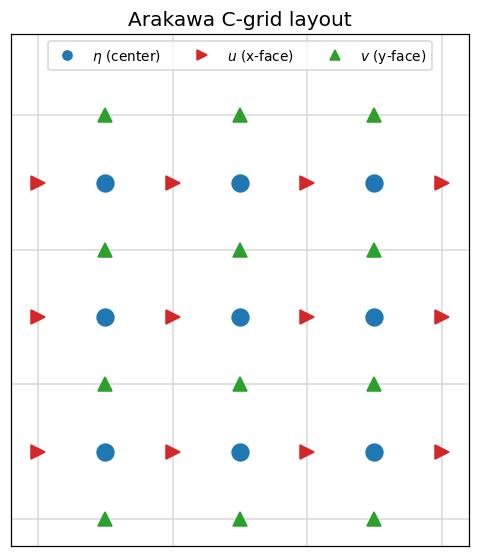

In [2]:
fig, ax = plt.subplots(figsize=(5.2, 5.2))
# 3x3 셀 격자 그림
n = 3
for i in range(n + 1):
    ax.axhline(i, color="0.85", lw=1); ax.axvline(i, color="0.85", lw=1)
xc = np.arange(n) + 0.5
Xc, Yc = np.meshgrid(xc, xc)
ax.plot(Xc, Yc, "o", color="C0", ms=11)                       # eta
xu = np.arange(n + 1); Xu, Yu = np.meshgrid(xu, xc)
ax.plot(Xu, Yu, ">", color="C3", ms=9)                        # u
yv = np.arange(n + 1); Xv, Yv = np.meshgrid(xc, yv)
ax.plot(Xv, Yv, "^", color="C2", ms=9)                        # v
ax.plot([], [], "o", color="C0", label=r"$\eta$ (center)")
ax.plot([], [], ">", color="C3", label=r"$u$ (x-face)")
ax.plot([], [], "^", color="C2", label=r"$v$ (y-face)")
ax.set_xlim(-0.2, n + 0.2); ax.set_ylim(-0.2, n + 0.6)
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
ax.set_title("Arakawa C-grid layout"); ax.legend(loc="upper center", ncol=3, fontsize=9)
fig.tight_layout(); fig.savefig(FIG / "02_cgrid_layout.png", bbox_inches="tight"); plt.show()

## 3. A / B / C-grid

같은 변수를 어디에 두느냐에 따라 격자를 분류한다.

- **A-grid**: $u,v,\eta$ 가 모두 같은 점(collocated). 구현은 쉽지만 압력경도에
  격자 잡음이 생긴다.
- **B-grid**: $\eta$ 는 중심, $u,v$ 는 셀 모서리(코너)에 함께. 코리올리 항에 유리.
- **C-grid**: $\eta$ 는 중심, $u$ 는 x-face, $v$ 는 y-face. 변형반지름이 격자로
  해상될 때 중력파 분산관계가 가장 정확해, 해양모델(ROMS·MOM 등)이 표준으로 쓴다.

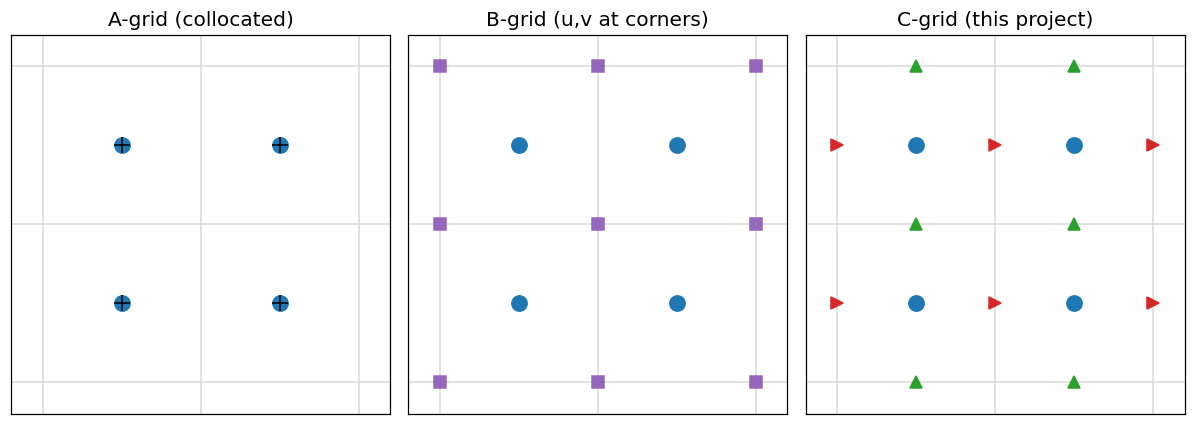

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.8))
for ax in axes:
    for i in range(3):
        ax.axhline(i, color="0.85", lw=1); ax.axvline(i, color="0.85", lw=1)
    ax.set_xlim(-0.2, 2.2); ax.set_ylim(-0.2, 2.2); ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
cc = np.array([0.5, 1.5])
Cx, Cy = np.meshgrid(cc, cc)
# A-grid: 모두 코너에 collocated (혹은 중심) — 여기선 중심에 모두
axes[0].plot(Cx, Cy, "o", color="C0", ms=10)
axes[0].plot(Cx, Cy, "+", color="k", ms=10)
axes[0].set_title("A-grid (collocated)")
# B-grid: eta 중심, u,v 코너
corners = np.array([0, 1, 2]); Bx, By = np.meshgrid(corners, corners)
axes[1].plot(Cx, Cy, "o", color="C0", ms=10)
axes[1].plot(Bx, By, "s", color="C4", ms=8)
axes[1].set_title("B-grid (u,v at corners)")
# C-grid
xu = np.array([0, 1, 2]); Ux, Uy = np.meshgrid(xu, cc)
Vx, Vy = np.meshgrid(cc, xu)
axes[2].plot(Cx, Cy, "o", color="C0", ms=10)
axes[2].plot(Ux, Uy, ">", color="C3", ms=8)
axes[2].plot(Vx, Vy, "^", color="C2", ms=8)
axes[2].set_title("C-grid (this project)")
fig.tight_layout(); fig.savefig(FIG / "02_grid_types.png", bbox_inches="tight"); plt.show()

## 4. 2차원 중력파 전파와 반사

정지 상태의 가우시안 봉우리를 닫힌 사각 분지(네 벽) 중앙에 두고 적분한다.
봉우리는 동심원 고리로 퍼져나가고($r\approx c\,t$), 벽에 닿으면 반사된다.

In [4]:
g, H = 1.0, 1.0
L, n = 200.0, 200
grid = CGrid(nx=n, ny=n, Lx=L, Ly=L)         # 닫힌 분지(기본: 벽)
model = ShallowWater2D(grid=grid, g=g, H=H, f0=0.0)
c = model.gravity_wave_speed()
dt = 0.4 * grid.dx / (c * np.sqrt(2))
print(f"dx = {grid.dx}, c = {c}, dt = {dt:.3f}, 2D CFL = {model.cfl(dt):.2f}")

X, Y = grid.meshgrid_eta()
eta0 = np.exp(-(((X - L/2)**2 + (Y - L/2)**2)) / (2 * 6.0**2))
u0 = np.zeros((n, n + 1)); v0 = np.zeros((n + 1, n))

T = 260.0
nsteps = int(round(T / dt))
res = model.run(eta0, u0, v0, dt, nsteps=nsteps, save_every=max(1, nsteps // 60))
print("snapshots:", len(res["eta_hist"]))

dx = 1.0, c = 1.0, dt = 0.283, 2D CFL = 0.40


snapshots: 62


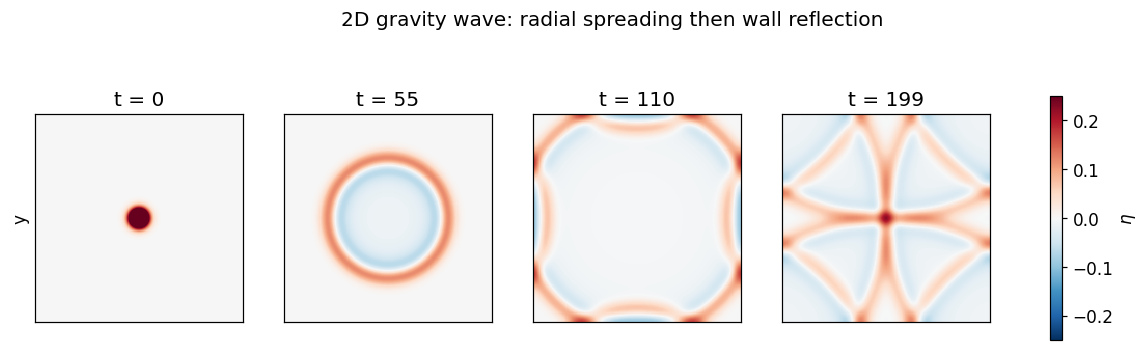

In [5]:
times = res["save_times"]
targets = [0.0, 55.0, 110.0, 200.0]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
vmax = 0.25
for ax, tt in zip(axes, targets):
    k = int(np.argmin(np.abs(times - tt)))
    im = ax.pcolormesh(X, Y, res["eta_hist"][k], cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                       shading="auto")
    ax.set_title(f"t = {times[k]:.0f}"); ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes, label=r"$\eta$", shrink=0.8)
axes[0].set_ylabel("y")
fig.suptitle("2D gravity wave: radial spreading then wall reflection", y=1.02)
fig.savefig(FIG / "02_radiation.png", bbox_inches="tight"); plt.show()

### 고리 반지름 $r\approx c\,t$ 확인

전파 초기(벽 반사 전)의 방사형 평균 프로파일을 보면, 고리의 봉우리가
$r=c\,t$ 위치에 있음을 확인할 수 있다.

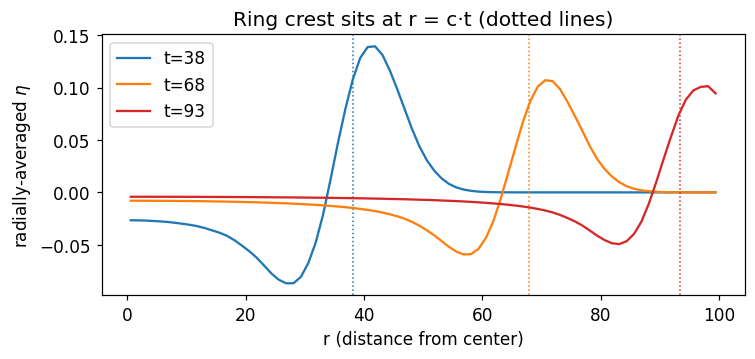

In [6]:
def radial_profile(field, X, Y, x0, y0, nbin=80, rmax=None):
    r = np.sqrt((X - x0)**2 + (Y - y0)**2).ravel()
    f = field.ravel()
    rmax = rmax or r.max()
    bins = np.linspace(0, rmax, nbin + 1)
    idx = np.digitize(r, bins) - 1
    prof = np.array([f[idx == k].mean() if np.any(idx == k) else np.nan
                     for k in range(nbin)])
    rc = 0.5 * (bins[:-1] + bins[1:])
    return rc, prof

fig, ax = plt.subplots(figsize=(7, 3.4))
for tt, col in zip([40.0, 70.0, 95.0], ["C0", "C1", "C3"]):
    k = int(np.argmin(np.abs(times - tt)))
    rc, prof = radial_profile(res["eta_hist"][k], X, Y, L/2, L/2, rmax=L/2)
    ax.plot(rc, prof, col, label=f"t={times[k]:.0f}")
    ax.axvline(c * times[k], color=col, ls=":", lw=1)
ax.set_xlabel("r (distance from center)"); ax.set_ylabel(r"radially-averaged $\eta$")
ax.set_title("Ring crest sits at r = c·t (dotted lines)"); ax.legend()
fig.tight_layout(); fig.savefig(FIG / "02_ring_radius.png", bbox_inches="tight"); plt.show()

## 5. 질량·에너지 보존

닫힌 분지에서 벽을 통한 흐름이 없으므로 총 질량 $\int\eta\,dA$ 은 정확히 보존되고,
총 에너지(운동+위치)는 발산하지 않고 유지되어야 한다.

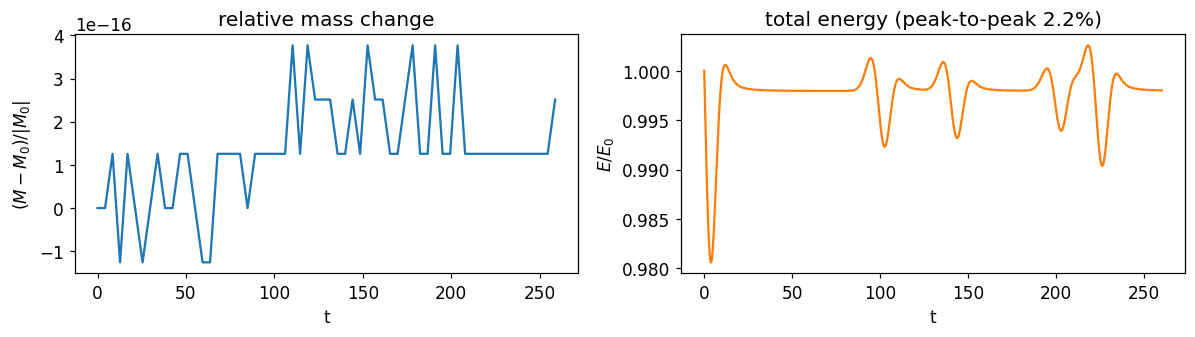

질량 상대변화 최대: 3.77e-16


In [7]:
mass = np.array([h.sum() * grid.dx * grid.dy for h in res["eta_hist"]])
E = res["energy"]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].plot(times, (mass - mass[0]) / (np.abs(mass[0]) + 1e-12))
axes[0].set_title("relative mass change"); axes[0].set_xlabel("t")
axes[0].set_ylabel(r"$(M-M_0)/|M_0|$")
axes[1].plot(res["times"], E / E[0], "C1")
axes[1].set_title(f"total energy (peak-to-peak {(E.max()-E.min())/E[0]*100:.1f}%)")
axes[1].set_xlabel("t"); axes[1].set_ylabel(r"$E/E_0$")
fig.tight_layout(); fig.savefig(FIG / "02_conservation.png", bbox_inches="tight"); plt.show()
print(f"질량 상대변화 최대: {np.max(np.abs(mass-mass[0]))/abs(mass[0]):.2e}")

## 6. 2차원 CFL 위반 시 폭주

2차원 CFL 수가 1을 넘으면(여기선 $\approx1.4$) 격자규모 모드가 폭발한다.

In [8]:
dt_bad = 1.0 * grid.dx / c          # 2D CFL = sqrt(2) ≈ 1.41 (>1)
with np.errstate(over="ignore", invalid="ignore"):
    rb = model.run(eta0, u0, v0, dt_bad, nsteps=150, track_energy=False)
print(f"불안정 dt: 2D CFL = {model.cfl(dt_bad):.2f},  max|η| = {np.nanmax(np.abs(rb['eta'])):.2e}")
print("→ CFL>1 이면 해가 발산한다(안정 적분은 위 4–5절처럼 CFL<1 이어야 한다).")

불안정 dt: 2D CFL = 1.41,  max|η| = 4.49e+96
→ CFL>1 이면 해가 발산한다(안정 적분은 위 4–5절처럼 CFL<1 이어야 한다).


## 7. 정리

- $u,v,\eta$ 를 **Arakawa C-grid** 에 배치해 2차원 중력파를 적분했다.
- 봉우리가 $r=c\,t$ 의 동심원으로 퍼지고 벽에서 반사되는 것을 확인했다.
- 닫힌 분지에서 **질량은 기계정밀도로 보존**, 에너지는 발산 없이 유지됐다.
- **2차원 CFL** $c\,\Delta t\sqrt{\Delta x^{-2}+\Delta y^{-2}}\le 1$ 가 안정조건이다.

다음(Stage 3)에서는 **코리올리 항**을 더해 회전의 효과 — 지형류 조정과
변형 반지름 — 를 다룬다.